## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [11]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import urllib
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.19.0


**QUESTION:** Load dataset and display some lines of the csv file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_embedded_ai/ai4i2020.csv")
df.head()


**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

Machine failure
0    9661
1     339
Name: count, dtype: int64


Text(0.5, 1.0, 'Failures distribution')

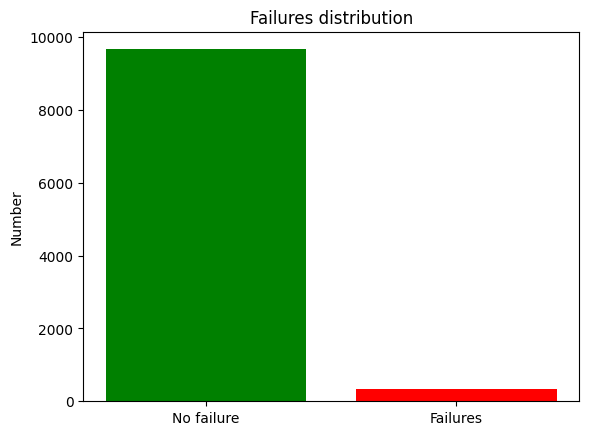

In [3]:
print(df['Machine failure'].value_counts())
counts = df['Machine failure'].value_counts()
plt.bar(counts.index,counts.values,color = ['green','red'])
plt.xticks([0,1],['No failure','Failures'])
plt.ylabel('Number')
plt.title('Failures distribution')

**ANALYSIS QUESTION:** What do you observe?




We observe that an approximate amount of 3.5% of failures on the total (339/9661)

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

The significant class imbalance (96.5% no failure vs 3.5% failures) will bias the model toward always predicting "No failure", achieving high accuracy while being useless at detecting actual failures. Standard accuracy becomes a misleading metric, maybe F1-score, recall and AUC-ROC are more appropriate. Solutions could include undersampling, oversampling, or applying class weights during training.

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

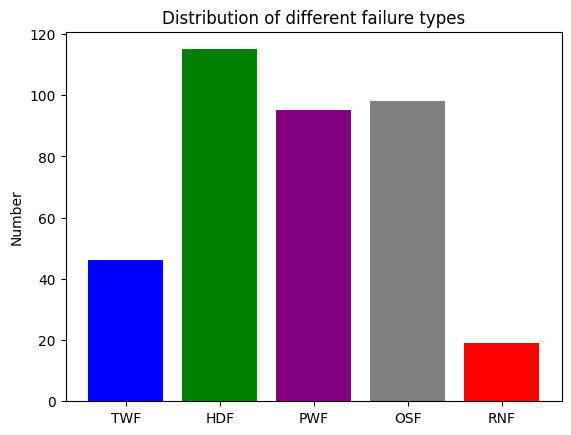

In [8]:

def distribution_failure_types(df) :
  twf = df['TWF'].sum()
  hdf = df['HDF'].sum()
  pwf = df['PWF'].sum()
  osf = df['OSF'].sum()
  rnf = df['RNF'].sum()

  height = [twf, hdf, pwf, osf, rnf]
  x = [0,1,2,3,4]

  plt.bar(x,height, color = ['blue','green','purple','gray','red'])

  plt.xticks([0,1,2,3,4], ['TWF','HDF','PWF','OSF','RNF'])
  plt.ylabel('Number')
  plt.title('Distribution of different failure types')

distribution_failure_types(df)


**ANALYSIS QUESTION:** What do you observe?

We observe that HDF is the most common failure type with about 115 occurrences, followed by OSF with about 98 and PWF with about 95. TWF has about 47 occurrences while RNF is the rarest with only about 20 cases.

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

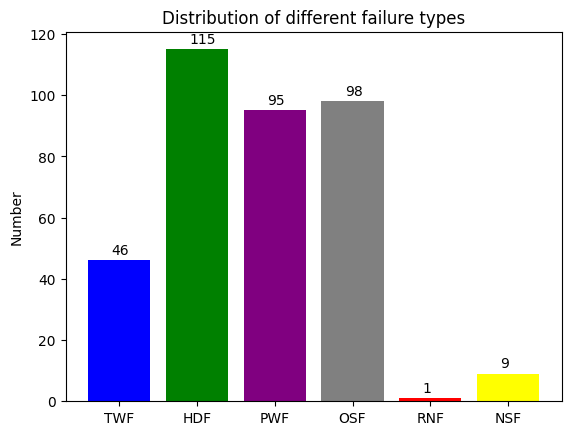

In [22]:
filtered_df = df[df['Machine failure']==1].copy()

condition = ( (filtered_df['TWF'] == 0) &
             (filtered_df['HDF'] == 0) &
             (filtered_df['PWF'] == 0) &
             (filtered_df['OSF'] == 0) &
             (filtered_df['RNF'] == 0) ) #condition is a panda Series with True and False values

filtered_df['No Specific Failure'] = condition.astype(int)

twf = filtered_df['TWF'].sum()
hdf = filtered_df['HDF'].sum()
pwf = filtered_df['PWF'].sum()
osf = filtered_df['OSF'].sum()
rnf = filtered_df['RNF'].sum()
nsf = filtered_df['No Specific Failure'].sum()

height = [twf, hdf, pwf, osf, rnf,nsf]
x = [0,1,2,3,4,5]
failure_type = ['TWF','HDF','PWF','OSF','RNF','NSF']

plt.bar(x,height, color = ['blue','green','purple','gray','red','yellow'])

plt.xticks(x, failure_type)
plt.ylabel('Number')
plt.title('Distribution of different failure types')

for i,h in zip(x,height) :
  plt.text(i-0.1,h+2,h)




**ANALYSIS QUESTION:** What do you observe comapred to the previous question ? What can you conclude?

Compared to the previous chart which showed all RNF cases, we observe that RNF drops drastically (from 20 to 1) when filtering only machines with Machine failure == 1. This suggests inconsistencies in the dataset : some RNF entries are recorded without a corresponding machine failure, which is logically contradictory. Additionally, 9 machines experienced a failure but had no specific failure type recorded (NSF), likely due to data entry errors or untracked failure modes. These data quality issues could introduce noise during model training and may require data cleaning beforehand.


**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [37]:
df.dtypes

,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

The inputs will be the physical measurements: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], and Type (after encoding, since it's currently a string/object). Columns like UDI and Product ID are just identifiers and should be excluded.
The outputs will be Machine failure (binary prediction: will it fail?) and the failure types TWF, HDF, PWF, OSF, RNF (what kind of failure?).
As observed previously, RNF shows inconsistencies (failures recorded without Machine failure == 1), so it may need to be treated carefully or excluded. The strong class imbalance (3.5% failures) also means the model must be evaluated beyond simple accuracy.


In [5]:
!git clone https://github.com/samibennane/stm32-embedded-ai-predictive-maintenance.git

Cloning into 'stm32-embedded-ai-predictive-maintenance'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.


In [6]:
%cd stm32-embedded-ai-predictive-maintenance

/content/stm32-embedded-ai-predictive-maintenance


In [9]:
!git branch -a
!git checkout -b feature/data-exploration origin/feature/data-exploration

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/feature/data-exploration
  remotes/origin/main
Branch 'feature/data-exploration' set up to track remote branch 'feature/data-exploration' from 'origin'.
Switched to a new branch 'feature/data-exploration'


In [10]:
!cp /content/drive/MyDrive/Colab\ Notebooks/TP_IA_EMBARQUEE.ipynb .

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/TP_IA_EMBARQUEE.ipynb': No such file or directory


## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

**QUESTION** Code below the model architecture

**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





**ANALYSIS QUESTION** What do you observe? What can you conclude?

"Write your response here"

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

"Write your response here"

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

**QUESTION** Code below the algorithms allowing to train model


**QUESTION** Plot the confusion matrix and the classification report

**ANALYSIS QUESTION** What do you observe? What can you conclude?

"Write your response here"